In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

Carregando os dados

In [ ]:
df = pd.read_csv("WineQT.csv")

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


Informações gerais

In [ ]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000,1143.000000
mean,8.311111,0.531339,0.268364,2.532152,0.086933,15.615486,45.914698,0.996730,3.311015,0.657708,10.442111,5.657043,804.969379
std,1.747595,0.179633,0.196686,1.355917,0.047267,10.250486,32.782130,0.001925,0.156664,0.170399,1.082196,0.805824,463.997116
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.392500,0.090000,1.900000,0.070000,7.000000,21.000000,0.995570,3.205000,0.550000,9.500000,5.000000,411.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,13.000000,37.000000,0.996680,3.310000,0.620000,10.200000,6.000000,794.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,61.000000,0.997845,3.400000,0.730000,11.100000,6.000000,1209.500000
max,15.900000,1.580000,1.000000,15.500000,0.611000,68.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1597.000000


In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Removendo a coluna Id

In [ ]:
df.drop("Id", axis=1, inplace=True)

Transformação da variável alvo

In [ ]:
df["quality_label"] = np.where(df["quality"] >= 7, 1, 0)

df[["quality","quality_label"]].head()

,quality,quality_label
0,5,0
1,5,0
2,5,0
3,6,0
4,5,0


Distribuição da variável alvo

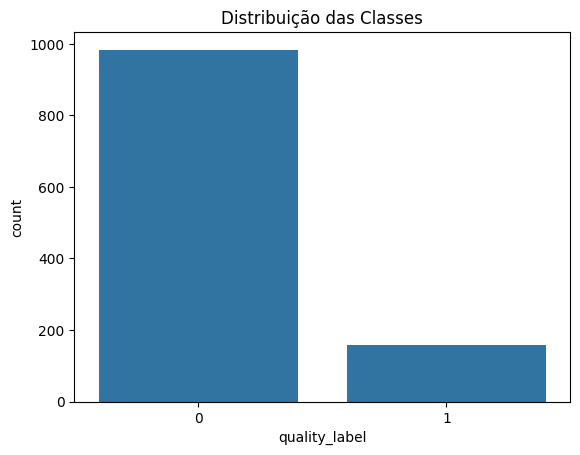

In [ ]:
sns.countplot(x="quality_label", data=df)

plt.title("Distribuição das Classes")
plt.show()

In [ ]:
df["quality_label"].value_counts(normalize=True)*100

,proportion
quality_label,
0,86.089239
1,13.910761


Distribuição das variáveis

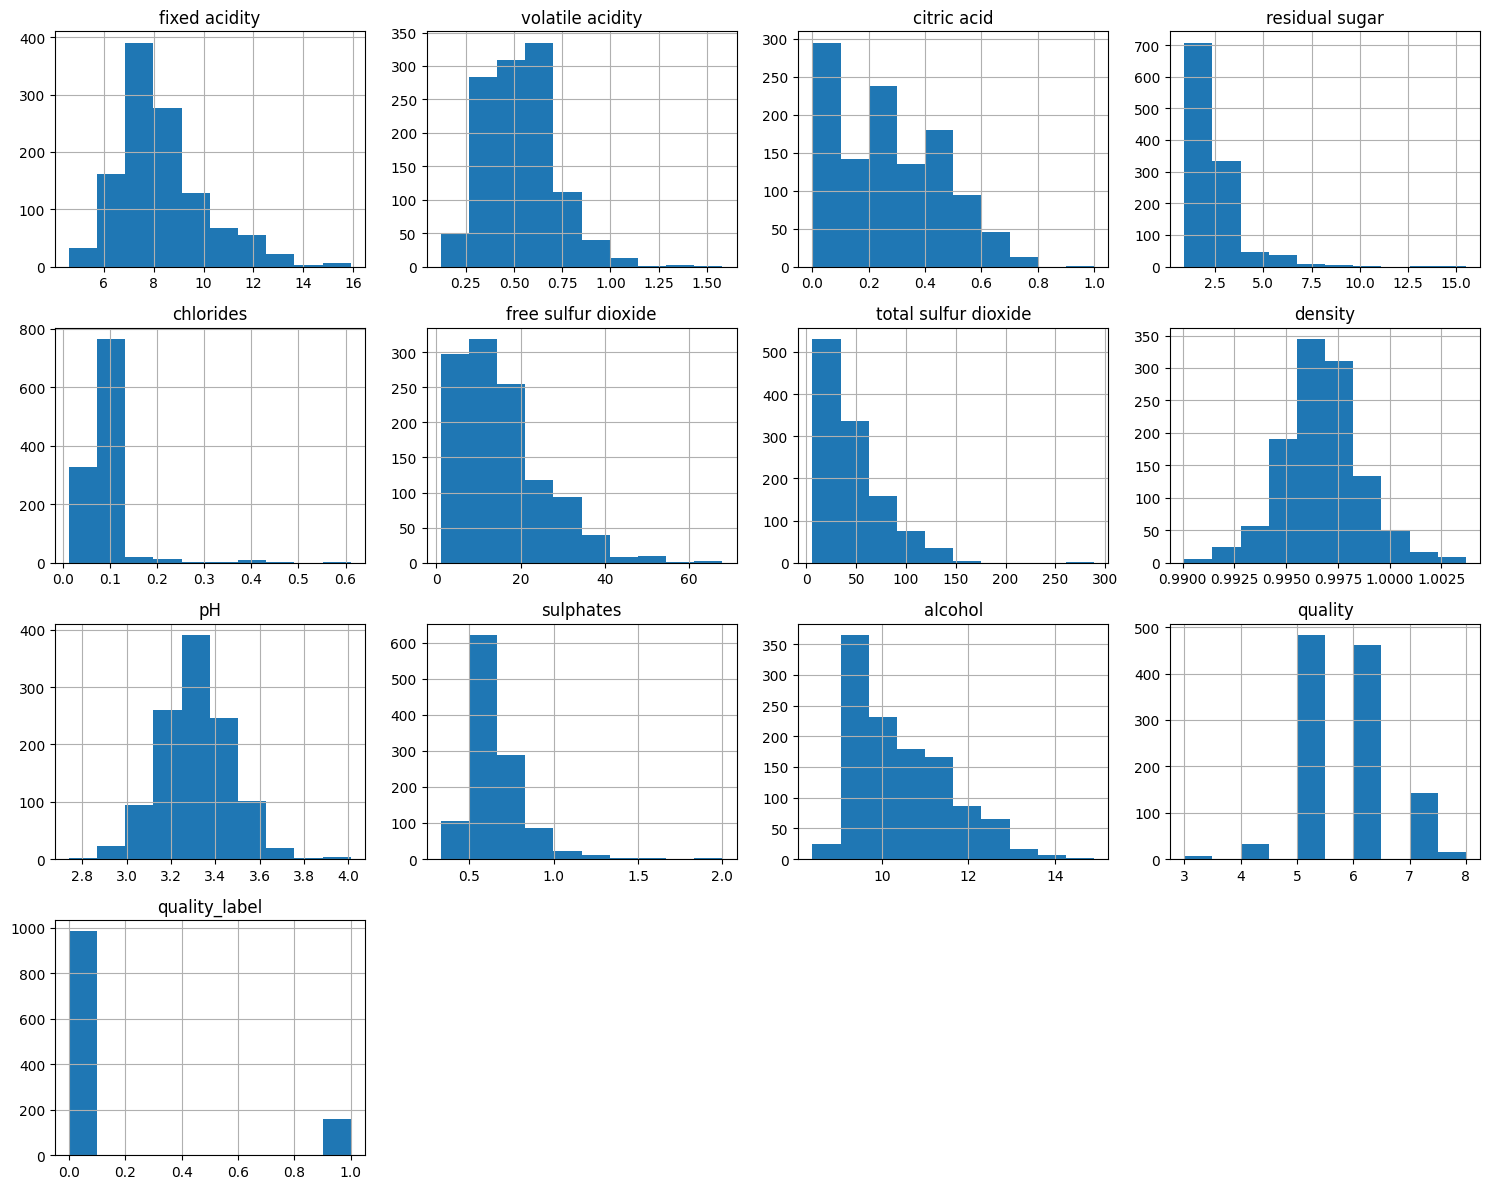

In [ ]:
df.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

Correlação

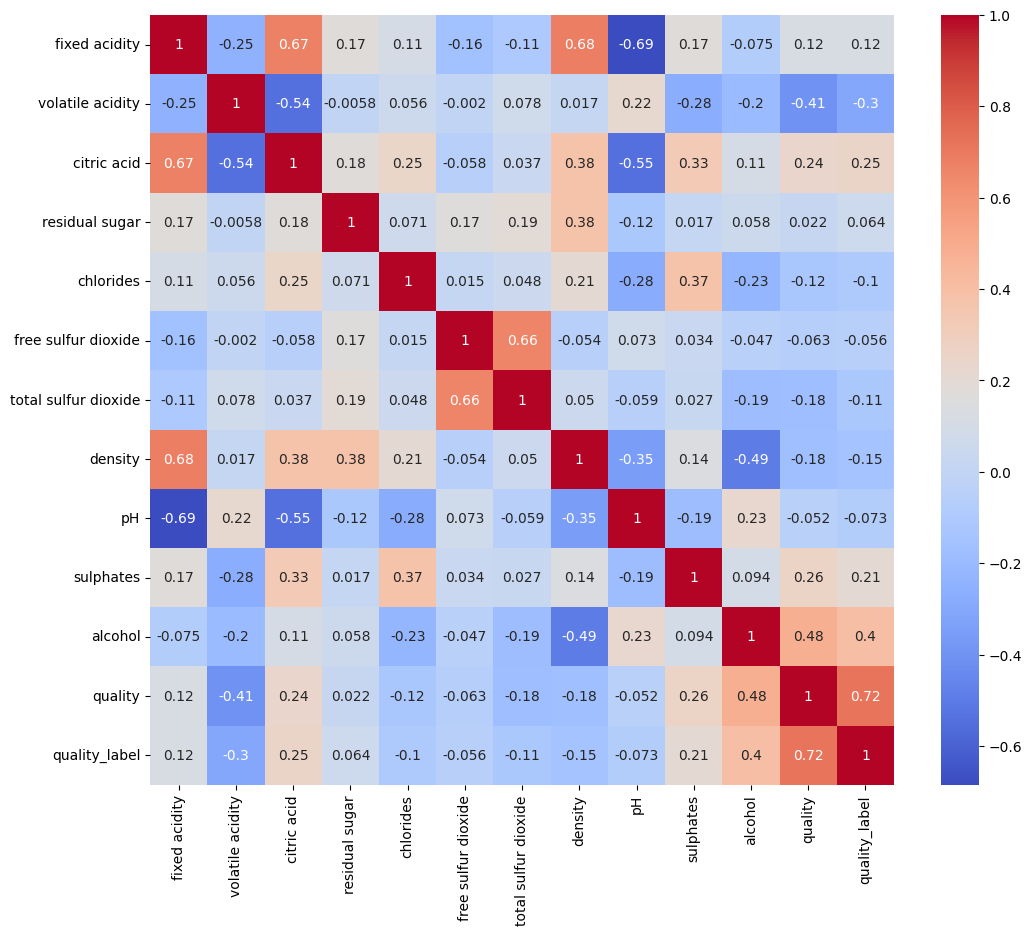

In [ ]:
plt.figure(figsize=(12,10))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

Boxplots

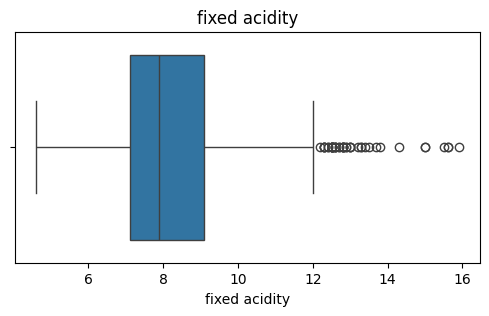

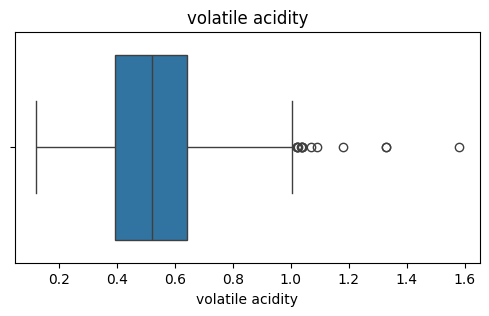

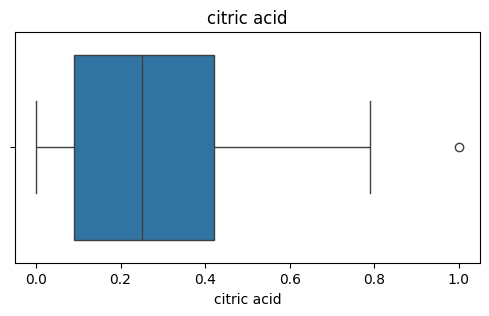

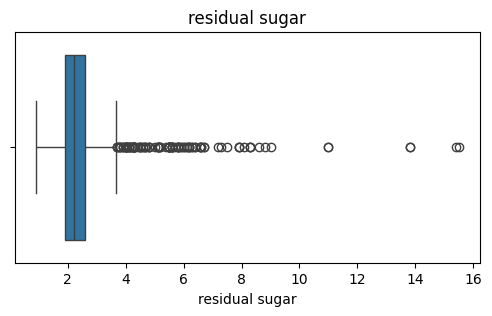

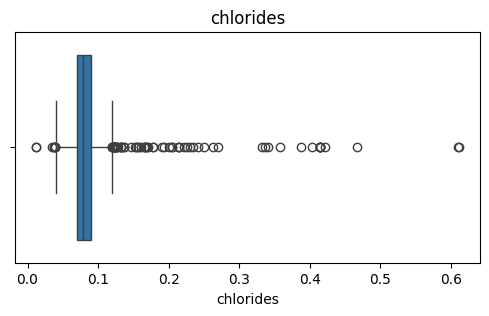

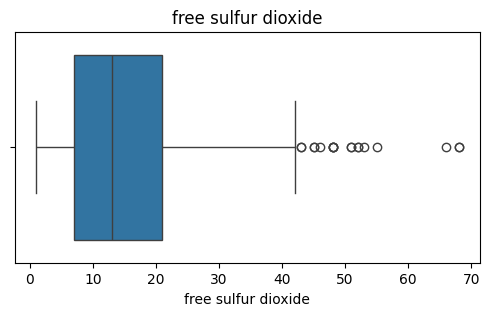

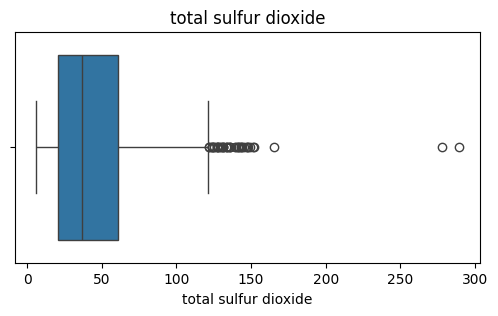

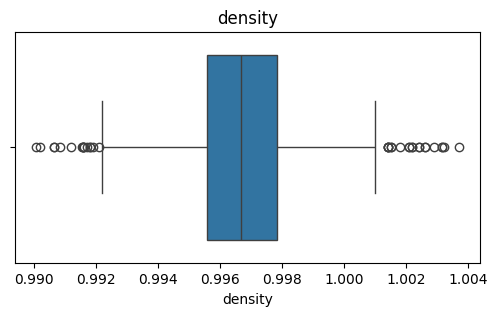

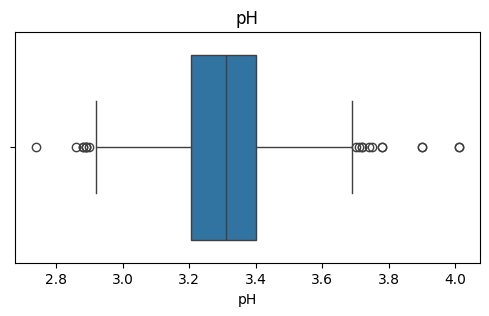

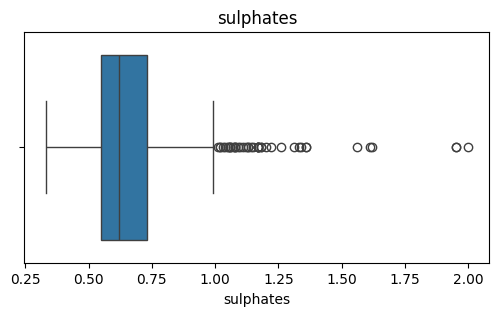

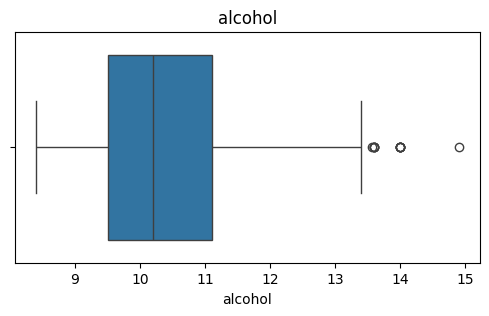

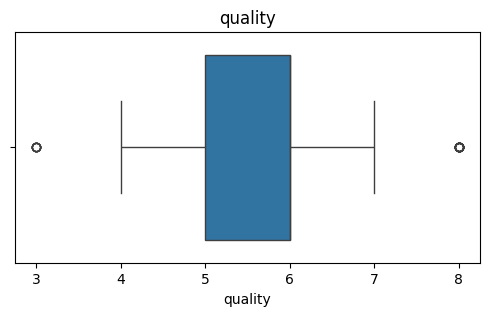

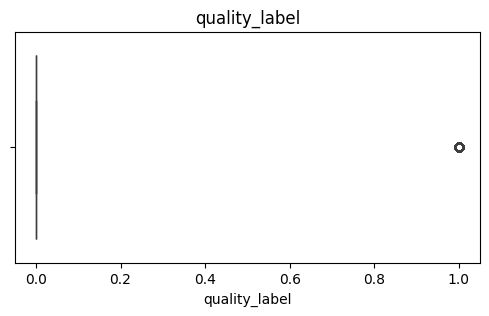

In [ ]:
for coluna in df.columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[coluna])

    plt.title(coluna)

    plt.show()

Separando variáveis

In [ ]:
X = df.drop(["quality","quality_label"], axis=1)

y = df["quality_label"]

Divisão treino/teste

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

Padronização

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Modelo 1 - Regressão Logística

In [ ]:
lr = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000
)

lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test,pred_lr))

print("Precision:", precision_score(y_test,pred_lr))

print("Recall:", recall_score(y_test,pred_lr))

print("F1:", f1_score(y_test,pred_lr))

print("ROC AUC:", roc_auc_score(y_test,pred_lr))

Accuracy: 0.7871720116618076
Precision: 0.3563218390804598
Recall: 0.6458333333333334
F1: 0.45925925925925926
ROC AUC: 0.7280014124293787


In [ ]:
print(classification_report(y_test,pred_lr))

              precision    recall  f1-score   support

           0       0.93      0.81      0.87       295
           1       0.36      0.65      0.46        48

    accuracy                           0.79       343
   macro avg       0.64      0.73      0.66       343
weighted avg       0.85      0.79      0.81       343



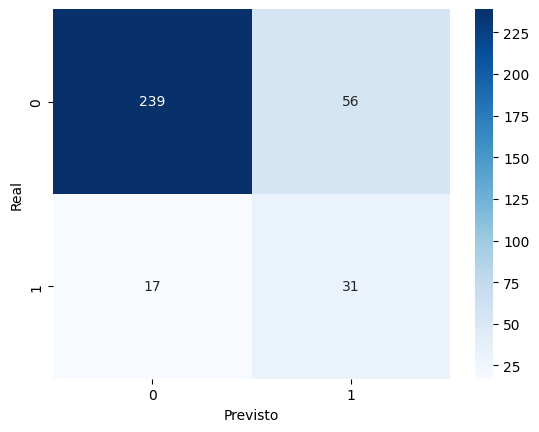

In [ ]:
cm = confusion_matrix(y_test,pred_lr)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Previsto")

plt.ylabel("Real")

plt.show()

Modelo 2 - Random Forest

In [ ]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test,pred_rf))

print("Precision:", precision_score(y_test,pred_rf))

print("Recall:", recall_score(y_test,pred_rf))

print("F1:", f1_score(y_test,pred_rf))

print("ROC AUC:", roc_auc_score(y_test,pred_rf))

Accuracy: 0.8892128279883382
Precision: 0.625
Recall: 0.5208333333333334
F1: 0.5681818181818182
ROC AUC: 0.7349929378531074


In [ ]:
print(classification_report(y_test,pred_rf))

              precision    recall  f1-score   support

           0       0.92      0.95      0.94       295
           1       0.62      0.52      0.57        48

    accuracy                           0.89       343
   macro avg       0.77      0.73      0.75       343
weighted avg       0.88      0.89      0.88       343



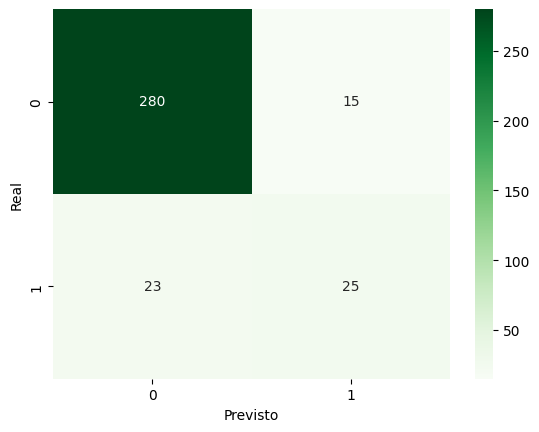

In [ ]:
cm = confusion_matrix(y_test,pred_rf)

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens")

plt.xlabel("Previsto")

plt.ylabel("Real")

plt.show()

Comparação dos modelos

In [ ]:
comparacao = pd.DataFrame({

    "Modelo":[
        "Regressão Logística",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_rf)
    ],

    "Precision":[
        precision_score(y_test,pred_lr),
        precision_score(y_test,pred_rf)
    ],

    "Recall":[
        recall_score(y_test,pred_lr),
        recall_score(y_test,pred_rf)
    ],

    "F1":[
        f1_score(y_test,pred_lr),
        f1_score(y_test,pred_rf)
    ]

})

comparacao

,Modelo,Accuracy,Precision,Recall,F1
0,Regressão Logística,0.857143,0.485714,0.354167,0.409639
1,Random Forest,0.892128,0.641026,0.520833,0.574713


Importância das variáveis

In [ ]:
importancias = pd.DataFrame({

    "Variável":X.columns,

    "Importância":rf.feature_importances_

})

importancias = importancias.sort_values(
    by="Importância",
    ascending=False
)

importancias

,Variável,Importância
10,alcohol,0.173486
1,volatile acidity,0.128165
9,sulphates,0.110265
2,citric acid,0.104859
7,density,0.095489
0,fixed acidity,0.076169
6,total sulfur dioxide,0.070348
4,chlorides,0.065862
3,residual sugar,0.064597
8,pH,0.059991


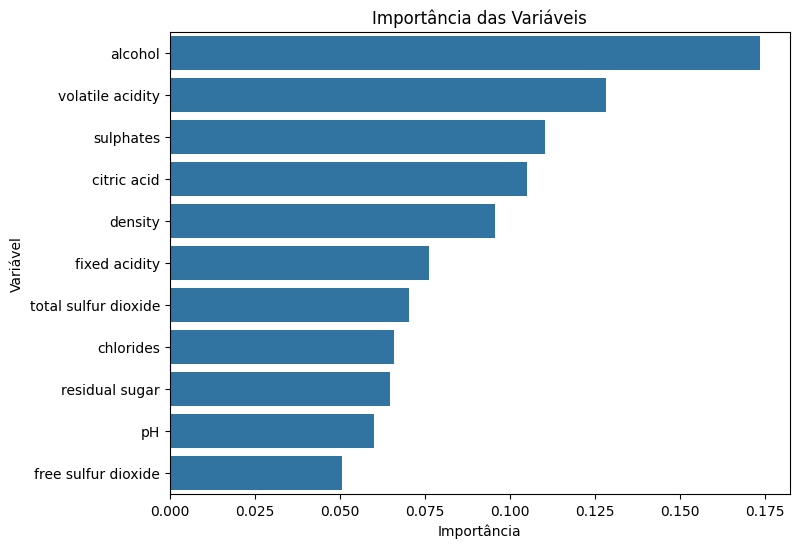

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importancias,
    x="Importância",
    y="Variável"
)

plt.title("Importância das Variáveis")

plt.show()